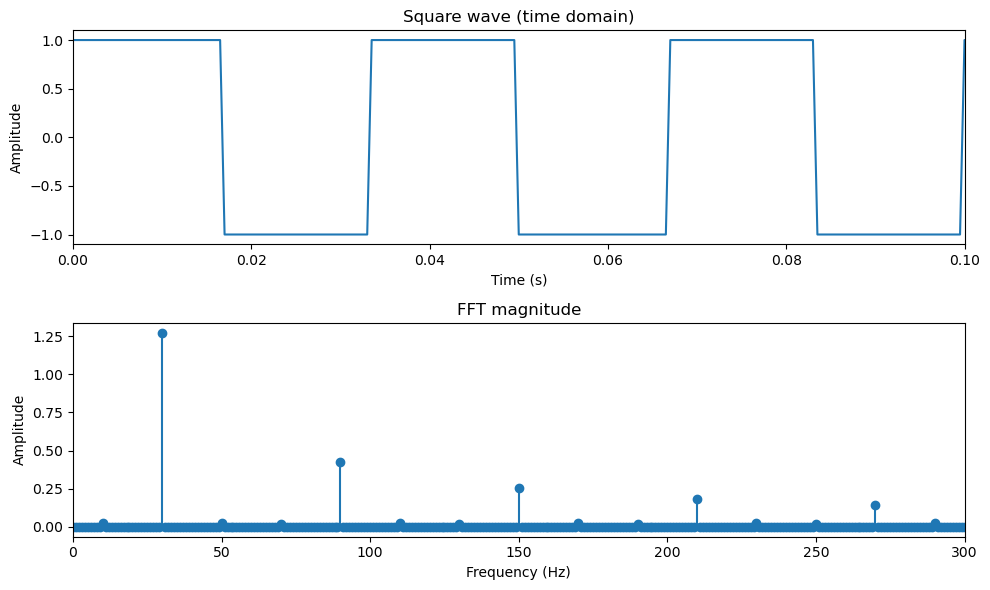

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------
# 1. basic parameters
# ------------------
fs = 2000.0          # sampling rate (Hz)
T = 1.0              # total duration (s)
f0 = 30.0            # fundamental frequency of the square wave (Hz)
duty = 0.5           # duty cycle (0..1); 0.5 = classic square
noise_amp = 0.0      # set to e.g. 0.1 to add noise

t = np.arange(0, T, 1/fs)  # time vector

# ------------------
# 2. create square wave
# ------------------
# make a pure sine at f0, then threshold to get a square
# alternatively, we can make a duty-cycle square by phase
phase = (f0 * t) % 1.0            # goes 0..1 for each period
x = np.where(phase < duty, 1.0, -1.0)

# add noise if you like
x = x + noise_amp * np.random.randn(len(x))

# ------------------
# 3. FFT
# ------------------
N = len(x)
X = np.fft.fft(x)
freqs = np.fft.fftfreq(N, d=1/fs)

# keep only the positive frequencies
pos_mask = freqs >= 0
freqs_pos = freqs[pos_mask]
X_pos = X[pos_mask]

# amplitude spectrum (scale by N to get sensible magnitude)
amp = np.abs(X_pos) * 2.0 / N     # 2/N because we dropped negative freqs

# ------------------
# 4. plot
# ------------------
plt.figure(figsize=(10, 6))

# time-domain
plt.subplot(2, 1, 1)
plt.plot(t, x)
plt.xlim(0, 3 / f0)   # zoom in on a few periods
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Square wave (time domain)")

# frequency-domain
plt.subplot(2, 1, 2)
plt.stem(freqs_pos, amp, basefmt=" ")
plt.xlim(0, 10 * f0)  # look at first several harmonics
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.title("FFT magnitude")
plt.tight_layout()
plt.show()